# Market Analysis

In [2]:
import pandas as pd 

In [32]:
# food = pd.read_csv(r'C:\Users\divya\OneDrive\Desktop\Project\New folder\u food marketing.csv')

In [5]:
pd.set_option('display.max.rows' ,2206)
pd.set_option('display.max.columns' ,50)

In [339]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Children,Marital Status,Education,Marketing Participated,Accepted_Cmp,Age_Grp,Education_Num
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,3,0,0,1529,1441,0,0,Single,Graduation,0,0,61-70,2.0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,3,0,0,21,15,0,2,Single,Graduation,0,0,61-70,2.0
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,3,0,0,734,692,0,0,Together,Graduation,0,0,51-60,2.0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,3,0,0,48,43,0,1,Together,Graduation,0,0,31-40,2.0
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0,1,Married,PhD,0,0,31-40,4.0


In [33]:
food.drop_duplicates(inplace=True)

In [35]:
food['Total Children'] = food['Kidhome'] + food['Teenhome']

In [41]:
import  numpy as np

In [45]:
condition =[
    food['marital_Divorced'] == 1,
    food['marital_Married'] == 1,
    food['marital_Single'] == 1,
    food['marital_Together'] == 1,
    food['marital_Widow'] == 1
]
choices = [
    'Divorced','Married','Single','Together','Widow'
]


In [47]:
food['Marital Status'] = np.select(condition,choices,default='Unknown')

In [51]:
food['education_Basic'] = food['education_Basic'].replace({1:4,0:0})
food['education_Graduation'] = food['education_Graduation'].replace({1:3,0:0})
food['education_Master'] = food['education_Master'].replace({1:2,0:0})

In [53]:
food['Education'] = food[['education_Basic','education_Graduation','education_Master','education_PhD']].sum(axis=1)

In [55]:
food['Education'] = food['Education'].map({4:'Basic',3:'Graduation',2:'Master',1:'PhD'})

In [70]:
food['Accepted_Cmp'] = (food['AcceptedCmpOverall'] !=0).astype(int)

In [84]:
food.corr(method = 'pearson', numeric_only=True)['Accepted_Cmp'].sort_values(ascending = False)

Accepted_Cmp              1.000000
AcceptedCmpOverall        0.859470
Marketing Participated    0.839928
AcceptedCmp4              0.557681
AcceptedCmp3              0.549849
AcceptedCmp5              0.539947
AcceptedCmp1              0.513571
MntWines                  0.462329
MntTotal                  0.411501
MntRegularProds           0.410940
Response                  0.364598
Income                    0.332099
NumCatalogPurchases       0.327884
MntMeatProducts           0.279368
AcceptedCmp2              0.220897
NumWebPurchases           0.214561
NumStorePurchases         0.188941
MntGoldProds              0.181021
MntSweetProducts          0.153188
MntFishProducts           0.151202
MntFruits                 0.129887
education_PhD             0.033729
Age                       0.018101
marital_Widow             0.014894
marital_Married           0.006303
marital_Single            0.004755
education_Master         -0.002002
education_Graduation     -0.002301
marital_Together    

In [88]:
age_groups = [(23, 30), (31, 40), (41, 50), (51, 60), (61, 70), (71, 85)]

def Age_find(Age):
    for i in age_groups:
        if i[0]<=Age<=i[1]:
            return f"{i[0]}-{i[1]}"
    return "Unknown"

In [89]:
food['Age_Grp'] = food['Age'].apply(Age_find)

In [90]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Children,Marital Status,Education,Marketing Participated,Accepted_Cmp,Age_Grp
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,3,0,0,1529,1441,0,0,Single,Graduation,0,0,61-70
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,3,0,0,21,15,0,2,Single,Graduation,0,0,61-70
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,3,0,0,734,692,0,0,Together,Graduation,0,0,51-60
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,3,0,0,48,43,0,1,Together,Graduation,0,0,31-40
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0,1,Married,PhD,0,0,31-40


In [91]:
import seaborn as sns

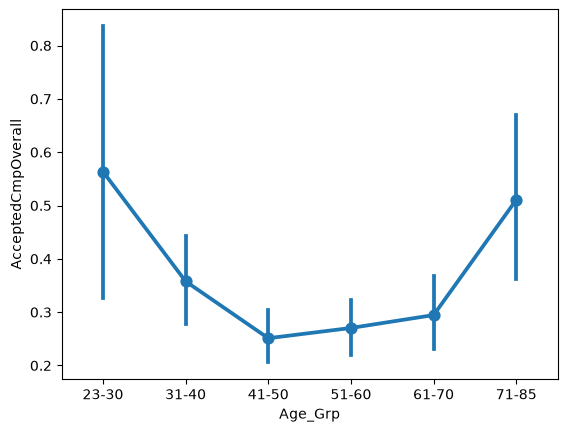

In [344]:
age_order = ['23-30', '31-40', '41-50', '51-60', '61-70', '71-85']
sns.pointplot(data=food, x='Age_Grp', y='AcceptedCmpOverall', order=age_order)

In [ ]:
#23–30 & 71–85 accept at higher rates, but small sample sizes (wide confidence intervals)

In [143]:
count = food['Age_Grp'].value_counts()

In [164]:
count

Age_Grp
41-50    669
51-60    455
61-70    421
31-40    327
71-85     94
23-30     55
Name: count, dtype: int64

In [144]:
percent = 100*count/food.shape[0]
percent = percent.reset_index()

In [145]:
percent.columns = ['ages','%age']

In [147]:
percent = percent.sort_values('ages')

In [155]:
percent.reset_index()

,index,ages,%age
0,5,23-30,2.721425
1,3,31-40,16.180109
2,0,41-50,33.102425
3,1,51-60,22.513607
4,2,61-70,20.831272
5,4,71-85,4.651163


In [156]:
percent.set_index('ages')

,%age
ages,
23-30,2.721425
31-40,16.180109
41-50,33.102425
51-60,22.513607
61-70,20.831272
71-85,4.651163


Text(0, 0.5, 'Customer Population Distribution by Age Group')

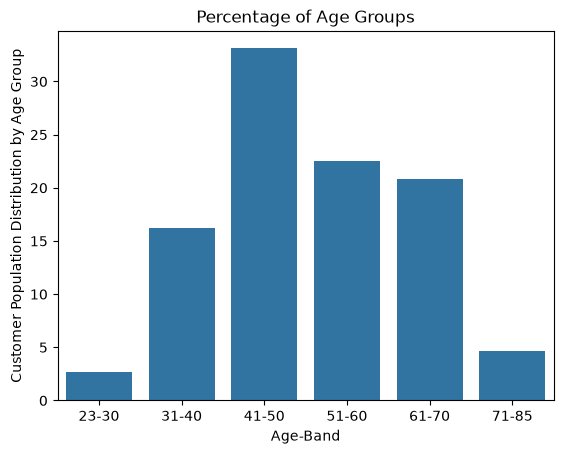

In [346]:
import matplotlib.pyplot as plt
sns.barplot(data=percent,x='ages',y='%age')
plt.title('Percentage of Age Groups')
plt.xlabel('Age-Band')
plt.ylabel('Customer Population Distribution by Age Group')

# 31–70 spend the most; 23–30 & 71–85 spend the least

In [167]:
AGrp_spending=food.groupby('Age_Grp')['MntTotal'].sum().reset_index()

Text(0.5, 1.0, 'Total Spend by Age Group (Campaign Acceptors)')

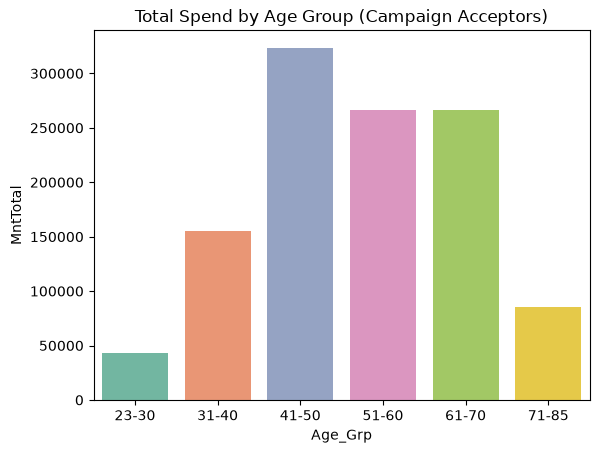

In [348]:
sns.barplot(data=AGrp_spending,x='Age_Grp',y='MntTotal',palette='Set2',hue='Age_Grp')
plt.title('Total Spend by Age Group (Campaign Acceptors)')

# Acceptors in younger/older groups catch up slightly, but 31–70 still dominate

In [169]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Children,Marital Status,Education,Marketing Participated,Accepted_Cmp,Age_Grp
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,3,0,0,1529,1441,0,0,Single,Graduation,0,0,61-70
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,3,0,0,21,15,0,2,Single,Graduation,0,0,61-70
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,3,0,0,734,692,0,0,Together,Graduation,0,0,51-60
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,3,0,0,48,43,0,1,Together,Graduation,0,0,31-40
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0,1,Married,PhD,0,0,31-40


In [240]:
sum_food = pd.DataFrame(
    food[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(),
    columns=['Sum']
)

In [241]:
sum_food.reset_index(inplace=True)

In [255]:
sum_food.rename(columns={'index':'Mode Of Purchase'},inplace=True)

Text(0.5, 0, 'Type')

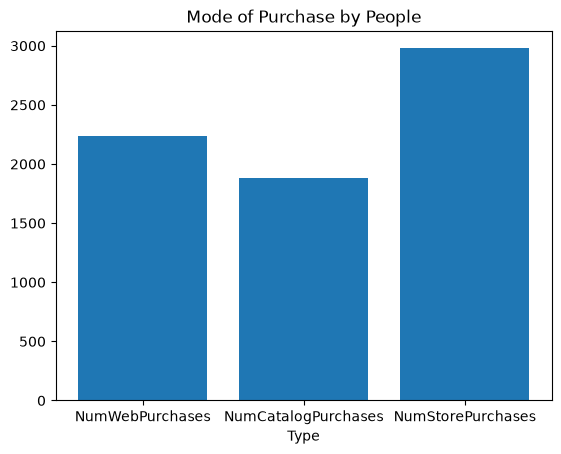

In [350]:
plt.bar(sum_food['Mode Of Purchase'] ,sum_food['Sum'])
plt.title('Mode of Purchase by People')
plt.xlabel('Type')

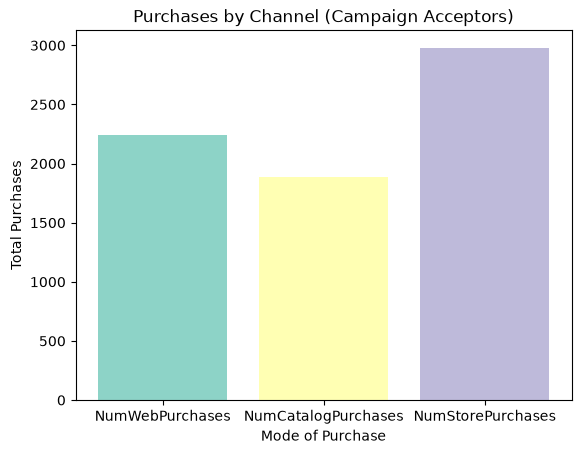

In [360]:
acc_cmp = food[food['Accepted_Cmp'] != 0]
sum_food = pd.DataFrame(
    acc_cmp[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(),
    columns=['Sum']
)
sum_food.reset_index(inplace=True)
sum_food.rename(columns={'index':'Mode Of Purchase'}, inplace=True)

# Apply colors
colors = sns.color_palette('Set3', n_colors=len(sum_food))
plt.bar(sum_food['Mode Of Purchase'], sum_food['Sum'], color=colors)
plt.title('Purchases by Channel (Campaign Acceptors)')
plt.xlabel('Mode of Purchase')
plt.ylabel('Total Purchases')
plt.show()

# People accepting more in Catalog Purchases for campaign than normally 

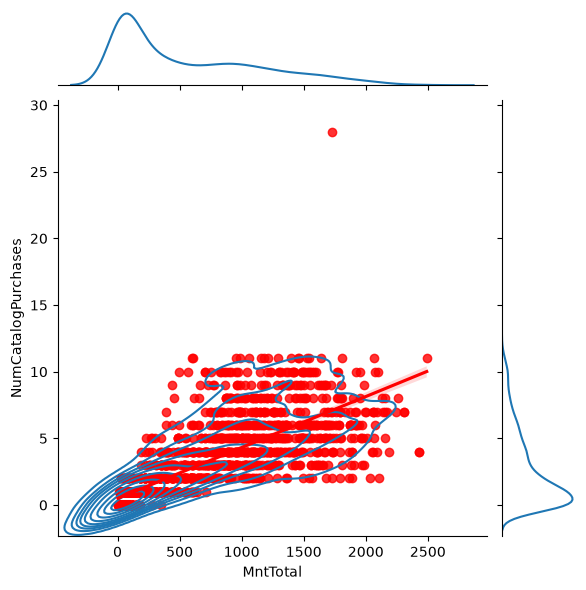

In [354]:
x = sns.jointplot(data=food, x='MntTotal', y='NumCatalogPurchases', kind='kde')
x.plot_joint(sns.regplot, color='red')

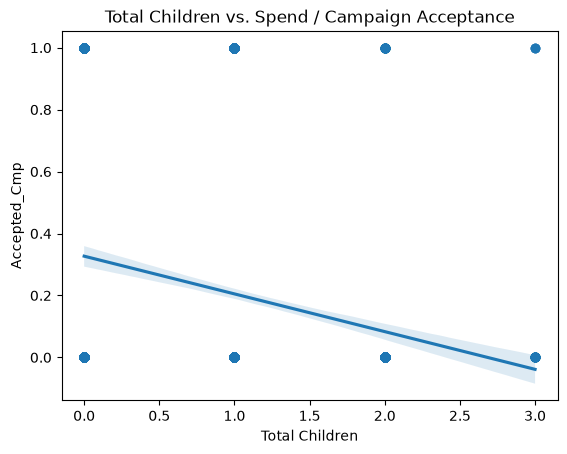

In [355]:
sns.regplot(x='Total Children',y='Accepted_Cmp',data=food)
plt.title('Total Children vs. Spend / Campaign Acceptance')


#  focus on people with no kids (or fewer kids)

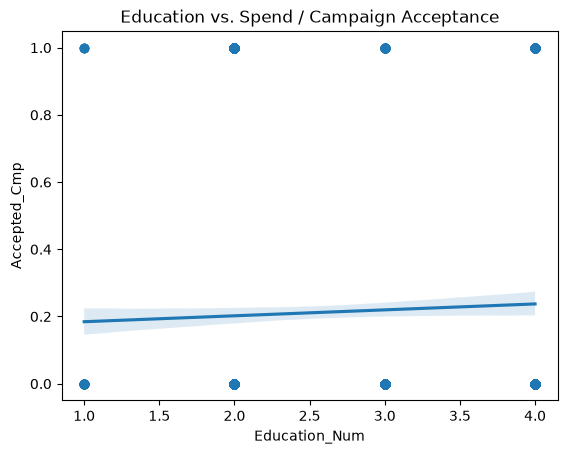

In [356]:
food['Education_Num'] = food['Education'].map({
    'Basic': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
})
sns.regplot(x='Education_Num', y='Accepted_Cmp', data=food.dropna())
plt.title('Education vs. Spend / Campaign Acceptance')

# No meaningful correlation

In [287]:
food.tail()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Children,Marital Status,Education,Marketing Participated,Accepted_Cmp,Age_Grp,Education_Num
2198,26816.0,0,0,50,5,1,6,3,4,3,1,0,0,3,4,0,0,0,0,0,0,3,11,0,34,2840,0,0,1,0,0,0,0,3,0,0,19,16,0,0,Single,Graduation,0,0,31-40,2.0
2200,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0,53,2540,0,1,0,0,0,0,0,3,0,0,1094,847,0,1,Married,Graduation,0,0,51-60,2.0
2202,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6,0,4,0,0,0,0,3,11,0,39,2314,1,0,0,0,0,0,0,3,0,0,1217,1193,1,0,Divorced,Graduation,4,1,31-40,2.0
2203,69245.0,0,1,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0,64,2315,0,0,0,1,0,0,0,0,2,0,782,721,0,1,Together,Master,0,0,61-70,3.0
2204,52869.0,1,1,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1,66,2781,0,1,0,0,0,0,0,0,0,1,151,130,0,2,Married,PhD,0,0,61-70,4.0


In [293]:
total_count_marital = food['Marital Status'].value_counts()

In [294]:
accepted_marital_count=food[food['Accepted_Cmp'] == 1] ['Marital Status'].value_counts()

In [295]:
percent_marital = 100*accepted_marital_count/total_count_marital

In [297]:
percent_marital = percent_marital.reset_index()

In [299]:
percent_marital.rename(columns={'count':'Percentage'})

,Marital Status,Percentage
0,Married,21.401274
1,Together,20.432220
2,Single,21.444695
3,Divorced,19.626168
4,Widow,24.285714


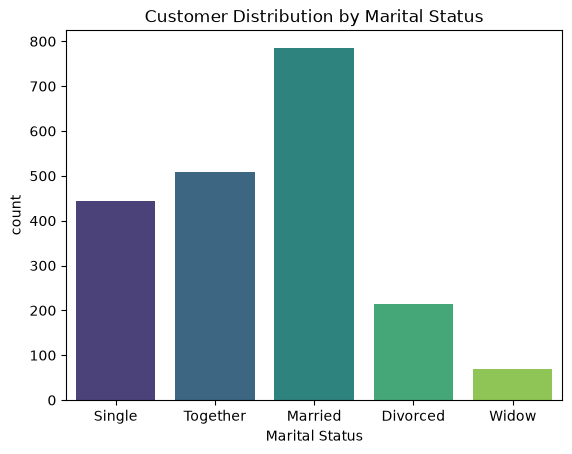

In [357]:
sns.countplot(x='Marital Status',  data=food,palette='viridis',hue='Marital Status')
plt.title('Customer Distribution by Marital Status')

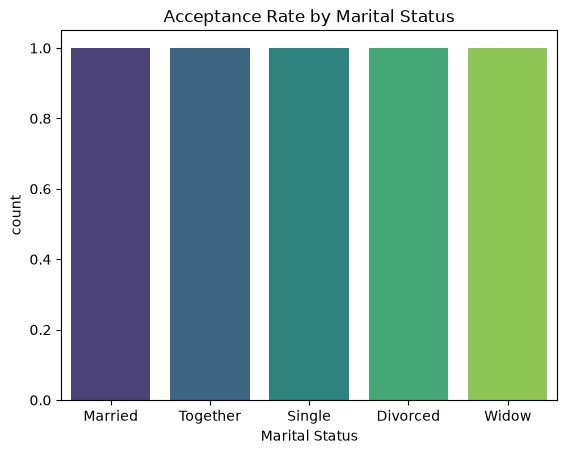

In [358]:
sns.countplot(x='Marital Status',  data=percent_marital ,palette='viridis',hue='Marital Status')
plt.title('Acceptance Rate by Marital Status')

# OVERALL FINDING

#### 1. Age: 30–70 year olds spend more money but are less likely to accept campaigns— higher volume here though.
#### 2. Purchase channels: Catalog was more likely to accept campaigns, but in-person spends more. Recommend a split — ~40% catalog, 30% store, 30% web.
#### 3. Kids: More kids = less accepting AND less spending. Focus on people with no kids (or fewer kids).
#### 4. Education: No impact. Don't target any specific group.
#### 5. Marital status: Married, Single, and Together spend a lot more.

## Money-making strategy: 
##### • Focus on middle-aged people, high earners, with no kids, targeted across platforms with the 40/30/30 split.
## New-user strategy:
##### • Focus on 21–30 and 70+ age groups — they accept campaigns at a higher rate, and since their population is currently small, there's more untapped market out there.

In [341]:
food.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Children,Marital Status,Education,Marketing Participated,Accepted_Cmp,Age_Grp,Education_Num
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,3,0,0,1529,1441,0,0,Single,Graduation,0,0,61-70,2.0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,3,0,0,21,15,0,2,Single,Graduation,0,0,61-70,2.0
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,3,0,0,734,692,0,0,Together,Graduation,0,0,51-60,2.0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,3,0,0,48,43,0,1,Together,Graduation,0,0,31-40,2.0
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0,1,Married,PhD,0,0,31-40,4.0
